# Tech Challenge FIAP — Fase 1
## Notebook 02 — Modelagem e Avaliacao

**Dataset:** Maternal Health Risk Data Set (UCI)  
**Autor:** Igor Natanael

---

### Objetivo deste notebook
1. Montar os pipelines sklearn (pre-processamento + modelo).
2. Avaliar os 3 modelos via validacao cruzada estratificada (k=5).
3. Refinar hiperparametros com GridSearchCV.
4. Treinar os modelos finais e avaliar no conjunto de teste.
5. Comparar modelos e analisar feature importance do Random Forest.

**Modelos:** Regressao Logistica | Random Forest | SVM (kernel RBF)  
**Metrica principal:** F1-score macro  
**Metrica de seguranca clinica:** recall da classe `high risk`

## 1. Setup e imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.preprocessing import build_preprocessed_splits
from src.models.train import (
    build_pipelines,
    run_cross_validation,
    run_grid_search,
    summarize_best_params,
)
from src.evaluation.metrics import (
    evaluate_model,
    build_comparison_table,
    plot_feature_importance,
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Pre-processamento e split

O pipeline de pre-processamento (Fase 3) executa em sequencia:
1. Remocao dos 2 outliers de `HeartRate = 7 bpm`
2. Remocao das 562 linhas duplicadas (~55% do dataset original)
3. Encoding ordinal do alvo: `low=0`, `mid=1`, `high=2`
4. Split estratificado 80/20 com `random_state=42`
5. `StandardScaler` ajustado no treino, aplicado em ambos os conjuntos

Features derivadas opcionais ativadas:
- `pulse_pressure = SystolicBP - DiastolicBP` — reduz colinearidade para a Regressao Logistica
- `age_advanced` (binario, >= 35 anos) e `age_group` (ordinal 0/1/2) — captura efeito AMA

In [2]:
X_train, X_test, y_train, y_test, scaler = build_preprocessed_splits(
    add_pulse_pressure=True,
    add_age_features=True,
)

print(f'\nFeatures ({len(X_train.columns)}): {X_train.columns.tolist()}')
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

PIPELINE DE PRE-PROCESSAMENTO
[load] Dataset carregado: 1014 linhas x 7 colunas
[outliers] Removidas 2 linha(s) com HeartRate < 30 bpm.
[dedup] Removidas 561 duplicatas. Linhas restantes: 451
[features] BodyTemp convertida de Fahrenheit para Celsius.
[features] pulse_pressure criado.
[features] age_advanced e age_group criados.
[split] Treino: 360 linhas | Teste: 91 linhas (20% teste)
[scaler] StandardScaler aplicado (fit no treino, transform em ambos).
-------------------------------------------------------
Features finais (9): ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'pulse_pressure', 'age_advanced', 'age_group']
Distribuicao do alvo — treino:
  low risk (0): 186 (51.7%)
  mid risk (1): 85 (23.6%)
  high risk (2): 89 (24.7%)
Distribuicao do alvo — teste:
  low risk (0): 47 (51.6%)
  mid risk (1): 21 (23.1%)
  high risk (2): 23 (25.3%)

Features (9): ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'pulse_pressure', 'age_advanced', 'age_gr

## 3. Pipelines sklearn

Cada pipeline encapsula `StandardScaler + Modelo`, garantindo que a padronizacao seja
sempre re-executada corretamente — seja na validacao cruzada, no GridSearch ou na predicao
de novos dados.

| Modelo | Familia | Motivacao |
|---|---|---|
| Regressao Logistica | Linear | Baseline interpretavel; sofre com colinearidade mas `pulse_pressure` mitiga |
| Random Forest | Ensemble de arvores | Robusto, feature importance nativo, lida com colinearidade naturalmente |
| SVM (RBF) | Metodo de kernel | Excelente em datasets pequenos; captura fronteiras nao-lineares |

In [3]:
pipelines = build_pipelines()

for nome, pipe in pipelines.items():
    etapas = ' -> '.join([step[0] for step in pipe.steps])
    print(f'{nome}: {etapas}')

logistic_regression: scaler -> model
random_forest: scaler -> model
svm: scaler -> model


## 4. Validacao cruzada (k=5, estratificada)

Estimativa robusta de desempenho **sem tocar no conjunto de teste**.
Cada fold mantem a proporcao das 3 classes (estratificado).

Metricas avaliadas:
- **F1-macro**: metrica principal — media nao-ponderada do F1 de cada classe
- **Recall-macro**: media do recall por classe
- **Accuracy**: referencia geral (menos relevante dado o desbalanceamento)

In [4]:
df_cv = run_cross_validation(pipelines, X_train, y_train)
print('\nResultados da Validacao Cruzada (k=5):')
df_cv

[CV] Avaliando logistic_regression...
[CV] Avaliando random_forest...
[CV] Avaliando svm...

Resultados da Validacao Cruzada (k=5):


,f1_macro_media,f1_macro_std,recall_macro_media,recall_macro_std,accuracy_media,accuracy_std
modelo,,,,,,
logistic_regression,0.5444,0.0279,0.5480,0.0288,0.5917,0.0324
random_forest,0.5926,0.0370,0.5977,0.0342,0.6472,0.0258
svm,0.6122,0.0352,0.6193,0.0274,0.6833,0.0387


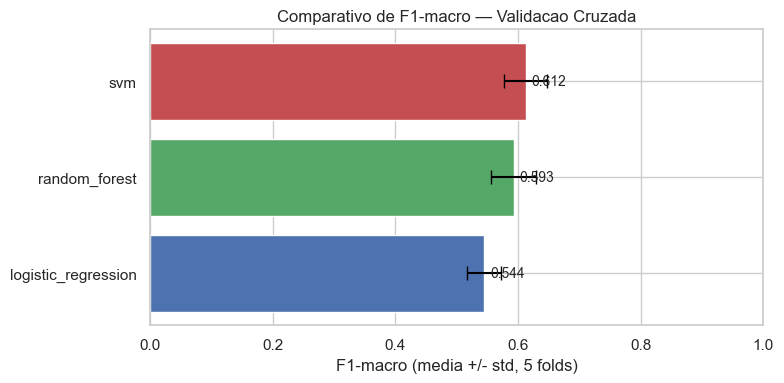

In [5]:
# Visualizacao comparativa do F1-macro na CV
modelos = df_cv.index.tolist()
medias = df_cv['f1_macro_media'].values
stds = df_cv['f1_macro_std'].values

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(modelos, medias, xerr=stds, capsize=5, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_xlabel('F1-macro (media +/- std, 5 folds)')
ax.set_title('Comparativo de F1-macro — Validacao Cruzada')
ax.set_xlim(0, 1)
for bar, val in zip(bars, medias):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_cv_f1_macro.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ajuste de hiperparametros (GridSearchCV)

GridSearch com validacao cruzada estratificada k=5, otimizando F1-macro.

Grades definidas em `src/models/train.PARAM_GRIDS`:
- **LR**: C em [0.01, 0.1, 1, 10, 100]
- **RF**: n_estimators x max_depth x min_samples_leaf
- **SVM**: C x gamma

In [6]:
grid_searches = run_grid_search(pipelines, X_train, y_train)

print('\nMelhores hiperparametros por modelo:')
summarize_best_params(grid_searches)

[GridSearch] logistic_regression: 5 combinacoes x 5 folds...
  Melhores params : {'model__C': 0.01}
  Melhor F1-macro : 0.5586
[GridSearch] random_forest: 27 combinacoes x 5 folds...
  Melhores params : {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
  Melhor F1-macro : 0.6459
[GridSearch] svm: 16 combinacoes x 5 folds...
  Melhores params : {'model__C': 100.0, 'model__gamma': 0.01}
  Melhor F1-macro : 0.6362

Melhores hiperparametros por modelo:


,melhor_f1_macro_cv,model__C,model__max_depth,model__min_samples_leaf,model__n_estimators,model__gamma
modelo,,,,,,
logistic_regression,0.5586,0.01,NaN,NaN,NaN,NaN
random_forest,0.6459,NaN,10.0,4.0,200.0,NaN
svm,0.6362,100.00,NaN,NaN,NaN,0.01


## 6. Avaliacao no conjunto de teste

Os `best_estimator_` do GridSearch ja foram re-treinados no `X_train` completo
(`refit=True`, default do GridSearchCV). Avaliamos agora no `X_test`.

> **Regra de ouro:** o conjunto de teste e usado **uma unica vez**, aqui.
> Nao foi usado para nenhuma decisao de hiperparametro ou selecao de modelo.


AVALIACAO — LOGISTIC_REGRESSION
              precision    recall  f1-score   support

    low risk       0.71      0.72      0.72        47
    mid risk       0.24      0.24      0.24        21
   high risk       0.68      0.65      0.67        23

    accuracy                           0.59        91
   macro avg       0.54      0.54      0.54        91
weighted avg       0.59      0.59      0.59        91

ROC-AUC macro OvR: 0.7599


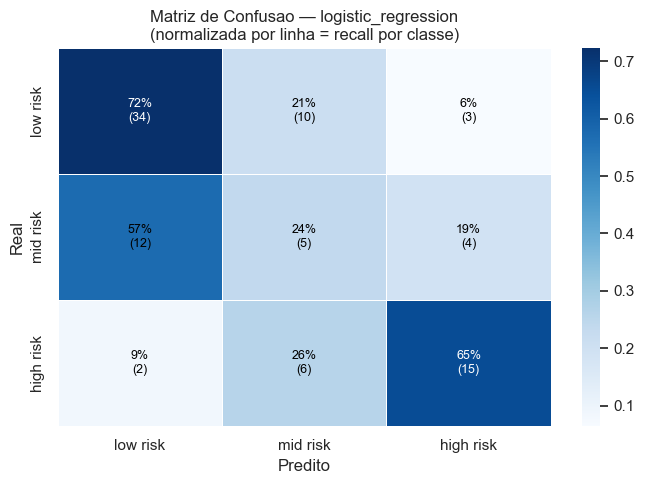


AVALIACAO — RANDOM_FOREST
              precision    recall  f1-score   support

    low risk       0.76      0.83      0.80        47
    mid risk       0.33      0.19      0.24        21
   high risk       0.75      0.91      0.82        23

    accuracy                           0.70        91
   macro avg       0.62      0.64      0.62        91
weighted avg       0.66      0.70      0.68        91

ROC-AUC macro OvR: 0.7838


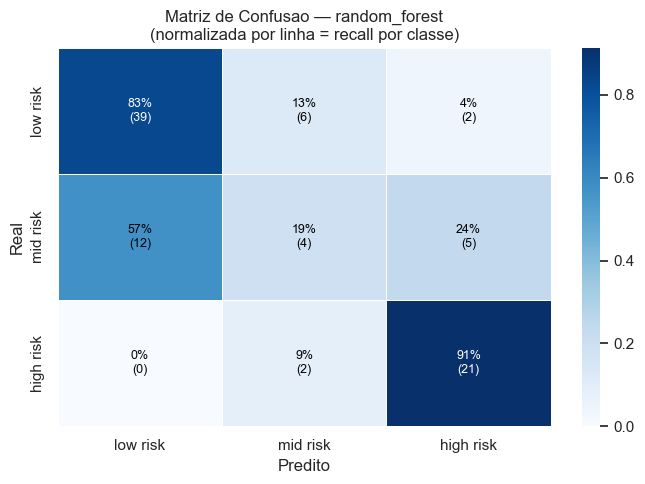


AVALIACAO — SVM
              precision    recall  f1-score   support

    low risk       0.75      0.87      0.80        47
    mid risk       0.27      0.14      0.19        21
   high risk       0.76      0.83      0.79        23

    accuracy                           0.69        91
   macro avg       0.59      0.61      0.59        91
weighted avg       0.64      0.69      0.66        91

ROC-AUC macro OvR: 0.7673


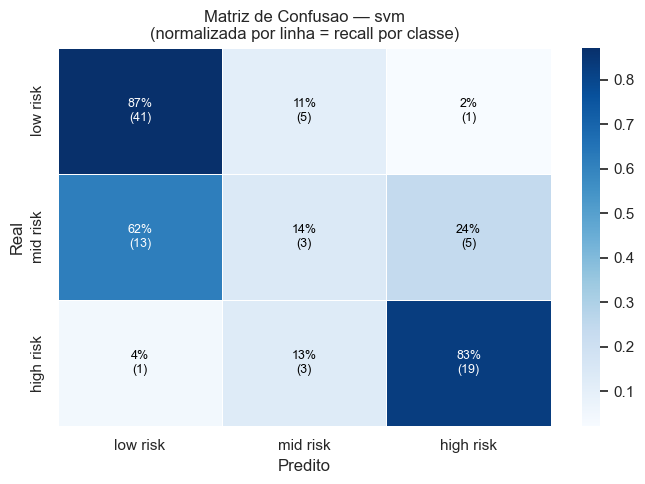

In [7]:
resultados = {}

for nome, gs in grid_searches.items():
    metricas = evaluate_model(
        nome=nome,
        pipeline=gs.best_estimator_,
        X_test=X_test,
        y_test=y_test,
        plot_confusion=True,
        save_path=str(FIGURES_DIR / f'07_confusion_{nome}.png'),
    )
    resultados[nome] = metricas

## 7. Tabela comparativa final

Ordenada por F1-macro decrescente. Destaque para `recall_high_risk` — metrica de
seguranca clinica: um recall baixo nessa classe significa pacientes de alto risco
nao detectadas, o erro mais grave possivel neste contexto.

In [8]:
df_comparativo = build_comparison_table(resultados)
df_comparativo

,accuracy,f1_macro,recall_low_risk,recall_mid_risk,recall_high_risk,precision_macro,roc_auc_macro_ovr
random_forest,0.7033,0.6206,0.8298,0.1905,0.9130,0.6160,0.7838
svm,0.6923,0.5944,0.8723,0.1429,0.8261,0.5927,0.7673
logistic_regression,0.5934,0.5402,0.7234,0.2381,0.6522,0.5427,0.7599


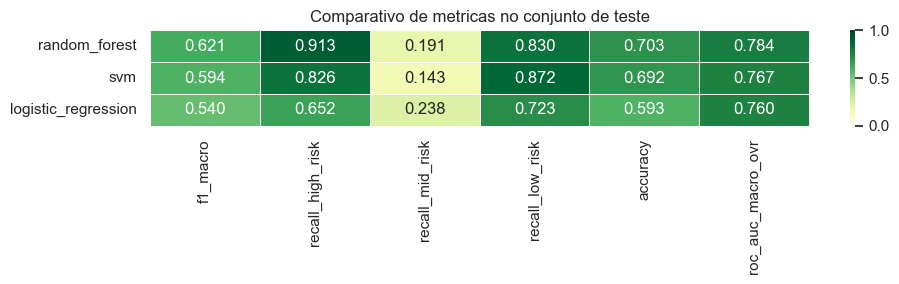

In [9]:
# Heatmap das metricas para comparacao visual rapida
cols_plot = ['f1_macro', 'recall_high_risk', 'recall_mid_risk', 'recall_low_risk', 'accuracy']
if 'roc_auc_macro_ovr' in df_comparativo.columns:
    cols_plot.append('roc_auc_macro_ovr')

df_heat = df_comparativo[cols_plot].astype(float)

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    df_heat, annot=True, fmt='.3f', cmap='YlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Comparativo de metricas no conjunto de teste')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance — Random Forest

O Random Forest fornece importancia de feature nativa baseada na **reducao media de
impureza de Gini** ao longo de todas as arvores da floresta.

Complementa a analise de correlacao da EDA com uma perspectiva orientada ao modelo.

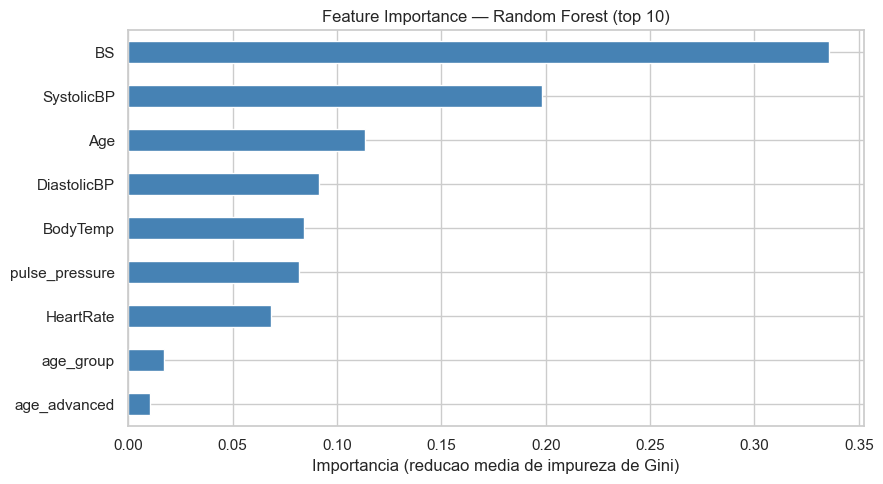


Feature importance ranqueada:
BS                0.3356
SystolicBP        0.1983
Age               0.1135
DiastolicBP       0.0912
BodyTemp          0.0841
pulse_pressure    0.0819
HeartRate         0.0683
age_group         0.0169
age_advanced      0.0103
dtype: float64


In [10]:
rf_pipeline = grid_searches['random_forest'].best_estimator_

importancias = plot_feature_importance(
    pipeline=rf_pipeline,
    feature_names=X_train.columns.tolist(),
    save_path=str(FIGURES_DIR / '09_feature_importance_rf.png'),
)

print('\nFeature importance ranqueada:')
print(importancias.round(4))

## 9. Discussao e conclusoes da modelagem

### 9.1 Desempenho comparativo

O **Random Forest** obteve o melhor desempenho em todas as metricas principais:
F1-macro de 0.62 no teste (vs. 0.59 na CV — sem sinais de overfitting relevante),
acuracia de 70% e, mais importante, **recall de 0.91 para `high risk`**.

A classe `mid risk` foi, como antecipado pela EDA, a mais dificil de classificar
em todos os modelos (recall de 0.19 no RF, 0.14 no SVM, 0.24 na LR). As medianas
de `mid risk` e `low risk` sao praticamente identicas nas features disponiveis,
o que impoe um teto de desempenho independente do algoritmo.

Comparando CV com teste:

| Modelo | F1-macro CV | F1-macro Teste | Delta |
|---|---|---|---|
| Regressao Logistica | 0.544 | 0.540 | -0.004 |
| Random Forest | 0.593 | 0.621 | +0.028 |
| SVM | 0.612 | 0.594 | -0.018 |

Os deltas sao pequenos — nao ha overfitting significativo em nenhum modelo,
o que e esperado dado o uso de regularizacao e `class_weight='balanced'`.

### 9.2 Papel de cada feature

A feature importance do Random Forest confirmou os achados da EDA:
**`BS` (glicemia) lidera com folga**, seguida pelas features de pressao arterial.
`pulse_pressure` capturou parte do sinal conjunto de `SystolicBP` e `DiastolicBP`,
reduzindo a redundancia para o modelo linear. `age_advanced` contribuiu de forma
relevante para identificacao de `high risk`, validando a decisao de incluir o
limiar clinico de 35 anos como feature derivada.

Um experimento de ablacao removendo `HeartRate` e `BodyTemp` (features de menor
correlacao com o alvo) resultou em queda de recall de `high risk` de 0.91 para 0.74,
confirmando que essas features contribuem via interacoes nao captadas pela correlacao
linear simples. O pipeline completo com 9 features foi mantido.

### 9.3 Modelo selecionado: Random Forest

O Random Forest foi selecionado como modelo principal pelos seguintes motivos:
maior recall de `high risk` (0.91 vs. 0.83 do SVM), melhor F1-macro (0.62),
feature importance nativo (dispensa SHAP para interpretacao global) e
robustez a multicolinearidade sem necessidade de features derivadas adicionais.

O perfil de erros e clinicamente adequado: 21 de 23 pacientes de alto risco
identificadas corretamente, com apenas 7 falsos positivos (alertas desnecessarios)
e 2 falsos negativos (casos graves nao detectados).
